# -----------------------------------

## October 2025. The Great Pumpkin King is about to take over the world. 
<img src="pumpkinking.png" width=100 height=100 /> 

## The only one that can stop him is the Octoknight. The Great Pumpkin King though, made sure to lock the Octoknight up. 

<img src="octoknight_lockedup.png" width=100 height=100 /> 


## Your mission, if you chose to accept it, is to help the Octoknight escape. To do this, you will need to bring together all your Python skill and things you have learned so far, as well as some Astronomy knowledge, to solve a few puzzles. In the process, you will retrieve the code that will free the Octoknight.

### Good luck!

### -----------------------------------

## 1. The start is half everything! ( $-$ Plato )

### a. Start by doing all necessary imports. Come back here to add imports as needed throughout the notebook. (4.5 points). 
Note that any imports left throughout the code will cost you 1 point per import!



In [1]:
# General imports
import os
import pickle
import numpy as np
import pandas as pd
import astropy.io.fits as fits
import matplotlib.pyplot as plt

# Unique imports
import radprof as rp
import gaussian as g
import midterm_amedina_support as sup

# Specifics
from astropy import modeling
from astropy.stats import sigma_clip
from scipy.optimize import curve_fit

### b. Start an empty list named *key* that will contain the key to release the Octoknight (.5 point)

In [2]:
key = []

### c. Don't forget to commit your project to GitHub often. If your laptop crashes close to the deadline there will be no chance of you saving the day (and getting a good grade in the process) if you haven't committed your progress in the meantime!

In [3]:
# Submit to GITHUB

### 2. Look at all these errors! (30 points)

### You turn around the corner. On the opposite wall there are weird shapes. You approach and you notice a keypad. Next to it there  two spheres that look like they orbit each other. You keep on looking around and notice the following curved at the bottom of one of the spheres:
$$\frac{V_1}{V_2} = 125.0 \pm ?? $$

#### *find the answer and press the right number for this door to open*. 

### You take a closer look and you notice on the spheres these numbers written: $40.0\pm0.3$, $8\pm0.2$. 

- Do the error propagation. What is the ??. Take into account the number of significant figures correctly and pay attention to the puzzle! (9 points).

In [4]:
# Each sphere has certain value

R1, dR1 = 40.0, 0.3
R2, dR2 = 8, 0.2

# Volume equation
# V = 4/3 * pi * R**3

V1 = (4/3) * np.pi * R1**3
dV1dR1 = 4 * np.pi * R1**2
dV1 = np.sqrt( (dV1dR1 * dR1)**2 )

V2 = (4/3) * np.pi * R2**3
dV2dR2 = 4 * np.pi * R2**2
dV2 = np.sqrt( (dV2dR2 * dR2)**2 )

# Presumed equation on sphere

Z = V1 / V2

dZdV1 = 1 / V2
dZdV2 = - V1 / V2**2

# ONLY 1 SIGNIFICANT DIGIT
dZ = np.sqrt( (dZdV1 * dV1)**2 + (dZdV2 * dV2)**2)

print('The full equation V1/V2 = {0}+-{1:.1f}'.format(np.round(Z), dZ))
print("So the number for the keypad is: {0:.1f}.".format(dZ))
print("So the answer for the keypad is: puzzle1_{0:.1f}.".format(dZ))

The full equation V1/V2 = 125.0+-9.8
So the number for the keypad is: 9.8.
So the answer for the keypad is: puzzle1_9.8.


### Did you solve the first puzzle? Type the code *puzzle1_\<youranswer>* to see if puzzle1.pdf opens!


### A door opens to a small room with an old-school desktop computer in the middle. You walk towards it to find more equations waiting there for you. 

### For the following, do the error propagation (**20 points**) and store the first decimal digit of the error (e.g., for $1.23\pm0.56$ you will keep the 5; don't do any rounding!) in a separate key (e.g., *key2*). Use this key to open file *puzzle2.pdf*. 
### *puzzle2.pdf* contains the first digit of your *key*. Append it to your *key* (1 point).

1. $ (2.42 \pm 0.12) \times (1.23 \pm 0.28) = $ ______ $\pm$ ______
2. $ (3.1 \pm 0.2) + (1.2 \pm 0.8) = $ ______ $\pm$ ______
3. $ \frac{2.4 \pm 0.4}{1.2 \pm 0.3} = $ ______ $\pm$ ______
4. $ (8.1 \pm 0.5) \times (3.23 \pm 0.64) = $ ______ $\pm$ ______
5. $ (3.1 \pm 0.3) + (1.2 \pm 0.1)^2 = $ ______ $\pm$ ______
6. $ \frac{1.43 \pm 0.21}{(7.32 \pm 0.83)^3} = $ ______ $\pm$ ______

In [5]:
key2 = []

In [6]:
# 1
x, dx = 2.42, 0.12
y, dy = 1.23, 0.28

# equation
z = x * y

dzdx = y
dzdy = x

dz = np.sqrt( (dzdx * dx)**2 + (dzdy * dy)**2 )
print('z +- dz = {0:.2f}+-{1:}'.format(z, dz))
print('So the first number: 6')

z +- dz = 2.98+-0.693489379875424
So the first number: 6


In [7]:
# 2
x, dx = 3.1, 0.2
y, dy = 1.2, 0.8

# equation
z = x + y

dzdx = 1
dzdy = 1

dz = np.sqrt( (dzdx * dx)**2 + (dzdy * dy)**2 )
print('z +- dz = {0:.2f}+-{1:}'.format(z, dz))
print('So the second number: 8')

z +- dz = 4.30+-0.8246211251235323
So the second number: 8


In [8]:
# 3
x, dx = 2.4, 0.4
y, dy = 1.2, 0.3

# equation
z = x / y

dzdx = 1 / y
dzdy = - x * y**(-2)

dz = np.sqrt( (dzdx * dx)**2 + (dzdy * dy)**2 )
print('z +- dz = {0:.2f}+-{1:}'.format(z, dz))
print('So the third number: 6')

z +- dz = 2.00+-0.6009252125773316
So the third number: 6


In [9]:
# 4
x, dx = 8.1, 0.5
y, dy = 3.23, 0.64

# equation
z = x * y

dzdx = y
dzdy = x

dz = np.sqrt( (dzdx * dx)**2 + (dzdy * dy)**2 )
print('z +- dz = {0:.2f}+-{1:}'.format(z, dz))
print('So the forth number: 4')

z +- dz = 26.16+-5.429740417368035
So the forth number: 4


In [10]:
# 5
x, dx = 3.1, 0.3
y, dy = 1.2, 0.1

# equation
z = x + y**2

dzdx = 1
dzdy = 2 * y

dz = np.sqrt( (dzdx * dx)**2 + (dzdy * dy)**2 )
print('z +- dz = {0:.2f}+-{1:}'.format(z, dz))
print('So the fifth number: 3')

z +- dz = 4.54+-0.38418745424597095
So the fifth number: 3


In [11]:
# 6
x, dx = 1.43, 0.21
y, dy = 7.32, 0.83

# equation
z = x / y**3

dzdx = 1 / y**3
dzdy = - 3 * x * y**(-4)

dz = np.sqrt( (dzdx * dx)**2 + (dzdy * dy)**2 )
print('z +- dz = {0:.2f}+-{1:}'.format(z, dz))
print('So the last number: 0')

z +- dz = 0.00+-0.001350834787239531
So the last number: 0


In [12]:
errors = 6, 8, 6, 4, 3, 0
key2.append(errors)

In [13]:
print(key2)

[(6, 8, 6, 4, 3, 0)]


In [14]:
# Key works
# The first digit is 7

key.append(7)

In [15]:
print(key)

[7]


### 3.  The signal to noise resolution (15 points)

### You are doing great so far! Let's look for the next clue. You look around and notice a piece of paper at the far corner of the room. You pick it up and read:

<img src="problem3_note.png" width=800 height=500 /> 


### All of this sounds familiar. You actually have a book that describes similar concepts. You can do this! 

#### Tip: read Howel 4.6 through 5 for a refresher of your memory 

In [16]:
# Known values

sigma_r = 3
stell_F = 900 # e- / s
pixels  = 13  # pixels

From Howel 4.6. S/N of a CCD is given by

$
\frac{S}{N} = \frac{N_*}{ \sqrt{{N_*} + {n_{pix}}( {N_S} + {N_D} + {N_R^2})}}
$

Where:

${N_*}$ = total number of photons collected (may be for several pixels)

${n_{pix}}$ = total number of pixels

${N_S}$ = total number of photons from sky

${N_D}$ = total number of dark electrons per pixel

${N_R^2}$ = total number of electrons per pixel resulting from read noise

[Howell, 73].

In [17]:
# For a single 5 second exposure, number of e-
t1       = 5            # s
sig_five = stell_F * t1 # e-
# For 10 exposures
signal1  = sig_five * 10

# For a single 50 second exposure
t2       = 50
signal2  = stell_F * t2 # e-

In [18]:
# There are no N_D or N_S
# For a single 5 second exposure
noi_five = np.sqrt( sig_five + pixels * sigma_r**2)
# For 10 exposures
noise1   = np.sqrt( signal1 + 10 * pixels * sigma_r**2)

# FOr a single 50 second exposure
noise2   = np.sqrt( signal2 + pixels * sigma_r**2)

# The S/N
SNR1 = signal1 / noise1
SNR2 = signal2 / noise2

print('For 10 5-second exposures, S/N = {0}'.format(SNR1))
print('For 50-second exposure, S/N = {0}'.format(SNR2))
print('So the next digits for the key are: {0}'.format(int(SNR2)))
print(
"""
The S/N of the single 50 second exposure is better because it only 
takes in the noise 1 time, for that single exposure, but for the 
10 5-second exposures, the noise is read 10 times over, somewhat
similar to an error propagation
""")

For 10 5-second exposures, S/N = 209.42695414584776
For 50-second exposure, S/N = 211.8567993035179
So the next digits for the key are: 211

The S/N of the single 50 second exposure is better because it only 
takes in the noise 1 time, for that single exposure, but for the 
10 5-second exposures, the noise is read 10 times over, somewhat
similar to an error propagation



In [19]:
key.append(211)

In [20]:
print(key)

[7, 211]


### 4. No pain no gain? (10 points)

### Happy that you found the answer, you turn the paper to leave it on a nearby desk and notice there is more text on the back: 

<img src="problem4_note.png" width=800 height=500 /> 

Assuming the Gaussian, the mean level in a flat field $ F_{bar} $ has a width of:

$ \sigma_{ADU}  = \frac{\sqrt{ F_{bar} * Gain}}{Gain}$

Which I rework as,

$ \sigma_{ADU}^2  = \frac{ F_{bar} * Gain}{Gain^2}$

$ \sigma_{ADU}^2  = \frac{ F_{bar} }{Gain}$

Therefore,

$ Gain  = \frac{ F_{bar} }{ \sigma_{ADU}^2 }$

[Howell, 72].

In [21]:
F_bar     = 32 # ADU
sigma_ADU = 2  # ADU

# Gain calculation from my work above

Gain      = F_bar / sigma_ADU**2
print('The gain is = {0} e- / ADU'.format(Gain))
print('So the next digit for the key is: {0}'.format(int(Gain)))

The gain is = 8.0 e- / ADU
So the next digit for the key is: 8


In [22]:
key.append(8)

In [23]:
print(key)

[7, 211, 8]


### 5. The sample study (15 points)

### Walking around, you notice a spectrum plotted on a computer screen. The plot has a big arrow on top of an emission line.  Read the contents of file *emission_spec.dat* in a variable. The file contains all the photon measurements across this particular emission line. 

- How many numbers are there? (1 point)

- Use the appropriate Python function to plot a histogram of the data. Use 20 bins of width 5 each. (3 points) 

- What function do the data seem to follow? (3 points) This is a typical, simple model that you can use for fitting your emission or absorption lines with.

- Use the appropriate analytic function to overplot ('fit') this function with the same mean and standard deviation as your data have. (4 points)

- Based on the part of the spectrum that you saw the line you know that it starts at about 1.35$\mu$m with a total width of about 0.1$\mu$m. Assume that the center of each of your bins corresponds to a measured wavelength ($\lambda$). What is the spectral resolution ($\Delta\lambda$=$\lambda_i - \lambda_{i-1}$) of these data? 

- Which absorption line does this correspond to? Use the mean molecular weight of this species as the next part of your *key*. Do this in a single line using the appropriate Python commands. (1 point)

In [24]:
# Loading in data

spectra = np.loadtxt('emission_spec.dat')
numbers = len(spectra)
print('There are {0} numbers in the spectra file.'.format(numbers))

There are 900 numbers in the spectra file.


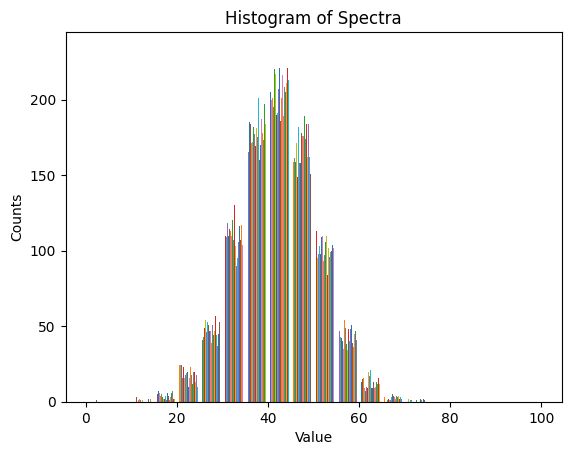

In [25]:
# Plot histrogram with 20 bins of width 5
# 5 * 20 = 100

binw   = 5
n_bins = np.arange(0, 101, binw)

plt.figure()
plt.hist(spectra, bins=n_bins)
plt.title("Histogram of Spectra")
plt.xlabel("Value")
plt.ylabel("Counts")
plt.show()

In [26]:
# Function

print('The data appears to follow a Gaussian (normal distribution).')

The data appears to follow a Gaussian (normal distribution).


Spectra mean and std are: 42.008505198998876 +- 8.614352376047393


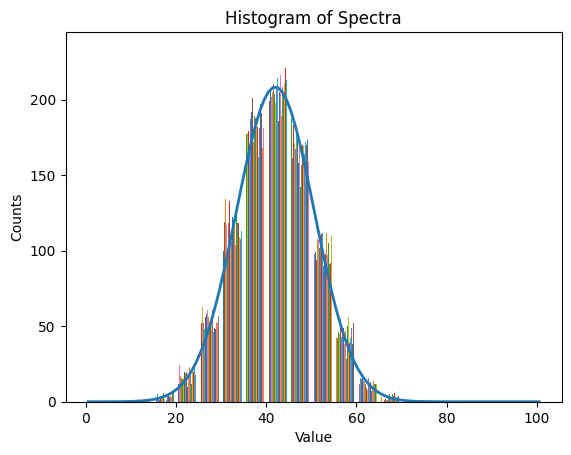

In [27]:
# Overplot with same mean and standard deviation

spectra_mu = np.mean(spectra)
spectra_st = np.std(spectra)
print('Spectra mean and std are: {0} +- {1}'.format(spectra_mu, spectra_st))

# Overplot values
gplot_values, bc_values = sup.gaussian(numbers, spectra_mu, spectra_st, binw)

plt.figure()
plt.hist(spectra, bins=n_bins)
plt.plot(bc_values, gplot_values, lw=2)
plt.title("Histogram of Spectra")
plt.xlabel("Value")
plt.ylabel("Counts")
plt.show()

In [28]:
# Spectrum line starts at 1.35 micron
# With a width of 0.1 micron
# Each bin is centered at a wavelength
# So the 0.1 micron spans 20 bins or

del_lambda = 0.1 / 20 # micron
print('The spectral resolution is: {0} micron'.format(del_lambda))

The spectral resolution is: 0.005 micron


In [29]:
# Around 1.35 to 1.45 micron
# Quick google search
# Within the liquid water absoprtion spectrum

print('Corresponds to absportion spectrum of H2O.')
print('H2O has a mmw of 18 g/mol.')

Corresponds to absportion spectrum of H2O.
H2O has a mmw of 18 g/mol.


In [30]:
key.append(18)

In [31]:
print(key)

[7, 211, 8, 18]


### 6. Counting photons (25 points)

###  You arrive at the top of the castle. There is a telescope there pointed at some weird object in the distance. You use it to take an image so that you can see what it points to. Unfortunately, the object is far away and you are not sure you have a good image, so you make multiple shots hoping for the best. Let's check your images out!

- Read-in the 80 images you took and stored in file *puzzle6images.pickle*. (3 points)
- Plot images 0, 3, 11, 45 and 75 in separate plots. How do your data look like? What do you think your SNR is? (4 points)
- Descrive what would you do to improve the situation. (7 points)
- Use your astronomical data analysis skills to get a good image out of your images. (8 points)
- What do you see in the final image? The answer is the next digit for your key (3 points)
- Append it to the key.

In [32]:
# Reading in the images
images6 = pickle.load(open('puzzle6images.pickle', 'rb'))

# There are 80 images and the dimensions are 21 x 67 for each image
N6, nx6, ny6 = images6.shape

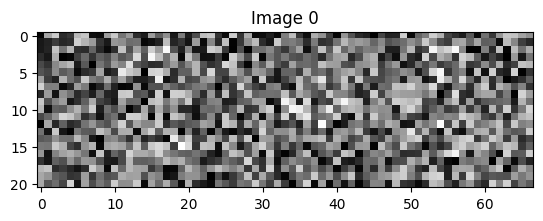

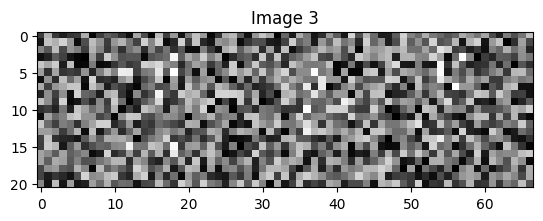

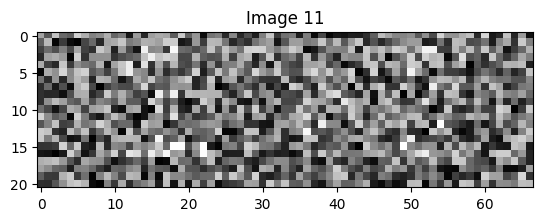

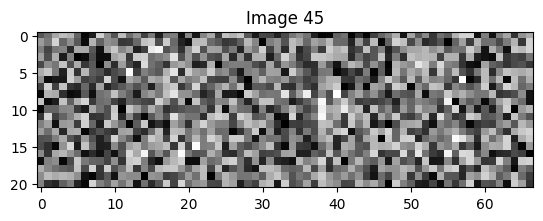

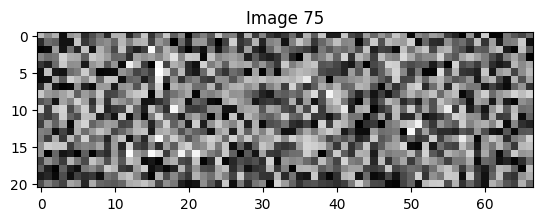

In [33]:
# Plotting specific images

index6 = [0, 3, 11, 45, 75]

for i in index6:
    image = images6[i, :, :]
    plt.figure()
    plt.imshow(image, cmap='gray')
    plt.title(f'Image {i}')
    plt.show()

In [34]:
print(
"""
The images just look like a lot of noise. This makes me
think that it has a low signal to noise ratio, something likely
lower than 3, perhaps around a 2 or 1.
""")


The images just look like a lot of noise. This makes me
think that it has a low signal to noise ratio, something likely
lower than 3, perhaps around a 2 or 1.



In [35]:
print(
"""
To improve the situtation, since we can't look at a different object,
we have to manipulate the images, like removing dark frames or normalizing
with a flat, but we don't have that either.


Based on previous homeworks, we can maybe mask some of the data, or use 
a sigma clipping algorithm to further mask the image.
""")


To improve the situtation, since we can't look at a different object,
we have to manipulate the images, like removing dark frames or normalizing
with a flat, but we don't have that either.


Based on previous homeworks, we can maybe mask some of the data, or use 
a sigma clipping algorithm to further mask the image.



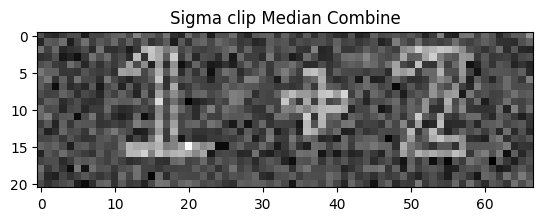

In [36]:
# Initializing sigma clipping
imsigm6 = np.zeros(images6.shape)

# Sigma clipping each image
for i in range(N6):
    imsigm6[i, :, :] = sigma_clip(images6[i, :, :], sigma=3, maxiters=5)

# Median combining
im_med6 = np.median(imsigm6, axis = 0)

# Median combined, sigma clipped image
plt.figure()
plt.imshow(im_med6, cmap='gray')
plt.title('Sigma clip Median Combine')
plt.show()

In [37]:
print('In the final image, I see a 1 + 2')
print('Which is a 3.')

key.append(3)

In the final image, I see a 1 + 2
Which is a 3.


In [38]:
print(key)

[7, 211, 8, 18, 3]


## 7. The image analysis (35 points)

### Things seem to be going smooth so far! You keep on looking for clues. Nearby, you notice a computer with a few observations plotted on the screen. 

- Read all observations in folder problem7_obs into one datacube (5 points) 
- Plot them (5 points) 
- Describe all the things you see in the images (2 points) 
- Proceed to work on the observations so that you clean up any artifacts. Use appropriate methods to find the center of the stars and do PSF fitting! (10 points)

- What are the center locations of the stars? (3 points)
- Plot the radial profiles for the 2 stars (6 points) 
- What are the heights of your PSFs? Subtract them from one another and add the int part to your key (4 points)

- Append it to your *key*. 

In [39]:
# Reading observations into one datacube

prob7dir = 'problem7_obs\\'
prob7lis = os.listdir(prob7dir)
N7       = len(prob7lis)

# Viewing shape to create emptpy
random   = 'model_obs_00.fits'
file     = fits.getdata(prob7dir + random)
nx7, ny7 = file.shape

# One datacube
starcube = np.zeros([N7, nx7, ny7])

# Append to datacube
for i in range(N7):
    starcube[i, :, :] = fits.getdata(prob7dir+ prob7lis[i])

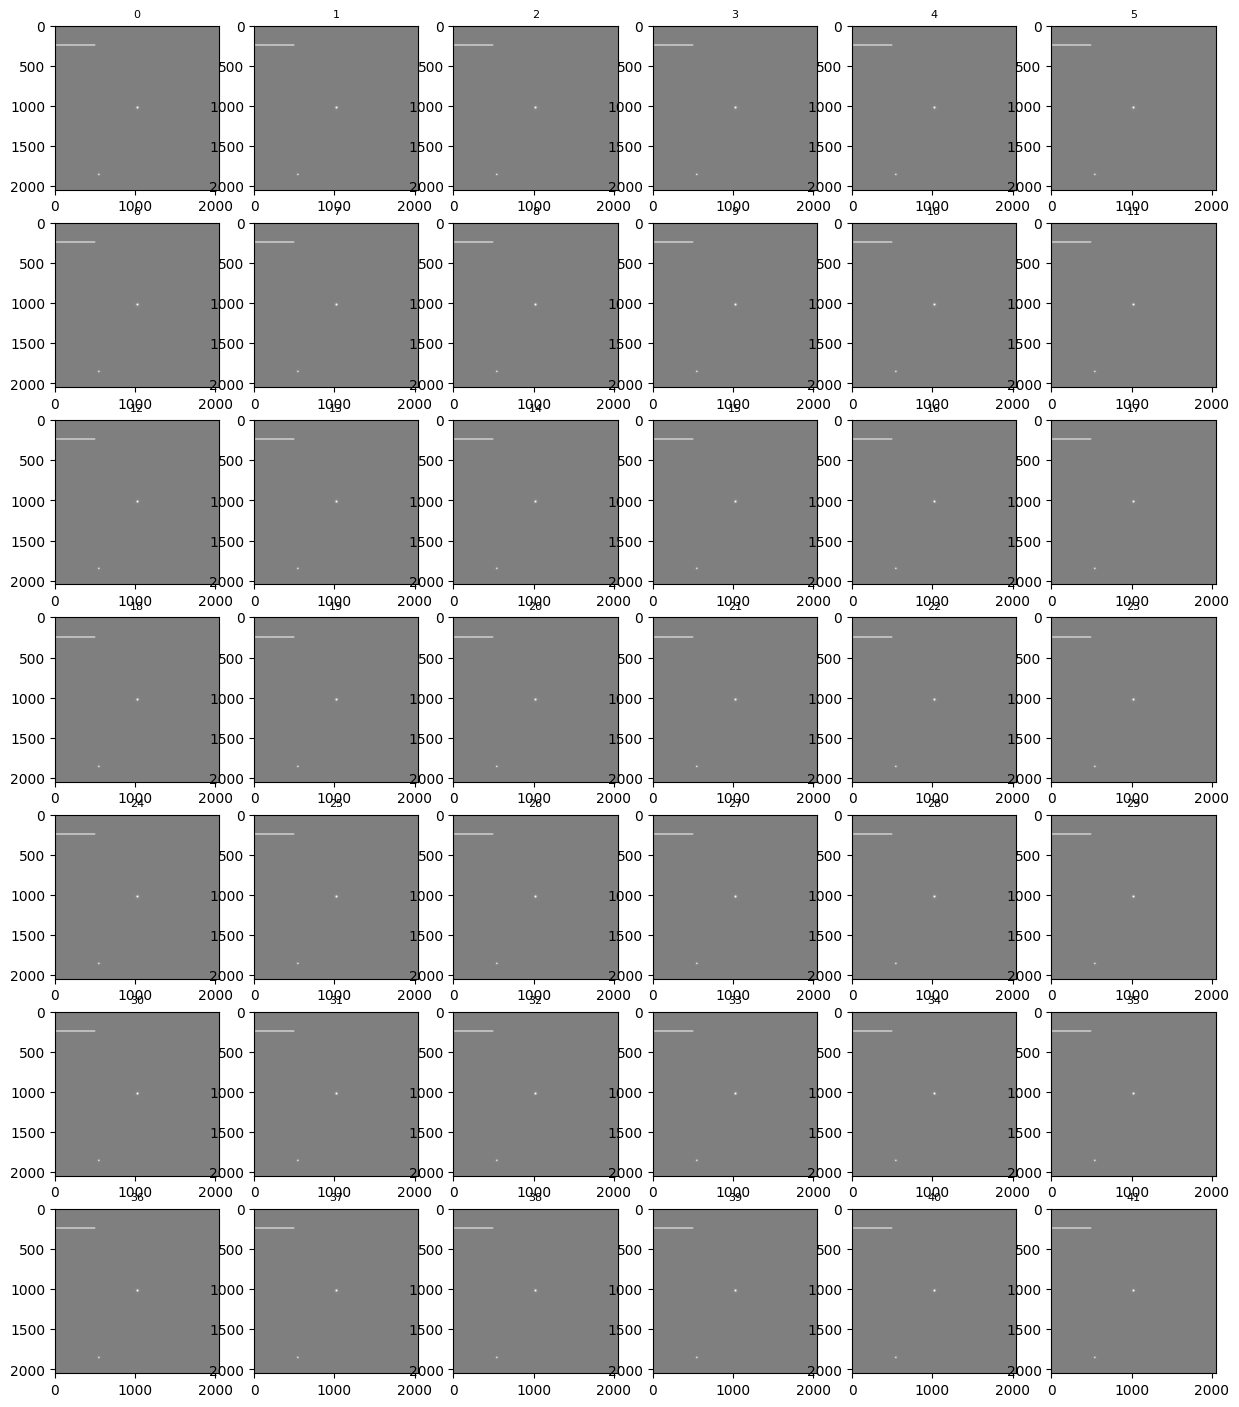

In [40]:
# Plotting all images

cols = 6
rows = int(np.ceil(N7 / cols))
qm = np.median(file)
qs = np.std(file)

plt.figure(figsize=(2.5 * cols, 2.5 * rows))
for i in range(N7):
    ax = plt.subplot(rows, cols, i + 1)
    ax.imshow(starcube[i], cmap='gray', vmin=qm-0.2*qs, vmax=qm+0.2*qs)
    ax.set_title(f'{i}', fontsize=8)
plt.show()

In [41]:
print(
"""
In the images, I see what looks like two stars, but somewhat faint.
And a streak that appears to be some sort of noise.
"""
)


In the images, I see what looks like two stars, but somewhat faint.
And a streak that appears to be some sort of noise.



In [42]:
# Cleaning up image with same routine as Q6

# Initializing sigma clipping
starsig = np.zeros(starcube.shape)

# Sigma clipping each image
for i in range(N7):
    starsig[i, :, :] = sigma_clip(starcube[i, :, :], sigma=3, maxiters=5)

# Median combining
starclean = np.median(starsig, axis = 0)

In [43]:
def findcenter(cleanimg, guess):
    """
    quess: array
        guesses for center x, y
        and width and height
    """
    (fw, fc, fh, fe) = g.fitgaussian(starclean, guess=guess)
    return fw, fc, fh, fe

star1guess = ((0.9, 0.9), (1853, 544), 650)
star2guess = ((0.9, 0.9), (1024, 1024), 650)

star1vals  = findcenter(starclean, star1guess)
star2vals  = findcenter(starclean, star2guess)

In [44]:
x1, y1 = star1vals[1][1], star1vals[1][0]
x2, y2 = star2vals[1][1], star2vals[1][0]

print('Center position of star 1 is x = {0}, y={1}'.format(x1, y1))
print('Center position of star 2 is x = {0}, y={1}'.format(x2, y2))

Center position of star 1 is x = 543.500003078316, y=1853.500019038197
Center position of star 2 is x = 1023.5000924995265, y=1023.5000178882292


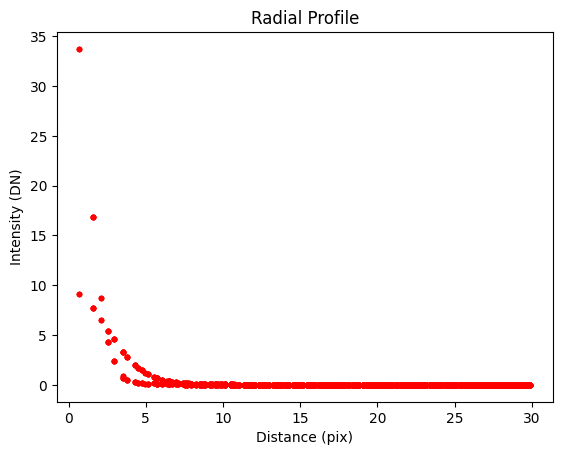

In [45]:
# Radial profile

pbin = 30

def get_radial_profile(image, center, rmax=30):
    """
    Compute the radial profile of a star image.

    Parameters
    ----------
    image : 2D array
        Image (e.g. median-combined or subimage of a star).
    center : tuple
        (y, x) center coordinates of the star.
    rmax : float, optional
        Maximum radius (pixels) to include in profile.

    Returns
    -------
    bins : array
        Radial bin centers.
    rp_vals : array
        Mean intensity values per bin.
    sr : array
        Sampled radii for simulated profile.
    sim : array
        Sampled intensities for simulated profile.
    incl : array
        Indices for radii within rmax.
    """
    bins, rp_vals, sr, sim = rp.radprof(image, center[0], center[1])
    incl = np.where(sr <= pbin)[0]
    return bins, rp_vals, sr, sim, incl

bins1, rp_vals1, sr1, sim1, incl1 = get_radial_profile(starclean, star1vals[1])
bins2, rp_vals2, sr2, sim2, incl2 = get_radial_profile(starclean, star2vals[1])

plt.figure()
plt.plot(sr1[incl1], sim1[incl1], '.r')
plt.plot(sr2[incl2], sim2[incl2], '.r')
plt.xlabel('Distance (pix)')
plt.ylabel('Intensity (DN)')
plt.title('Radial Profile')
plt.show()

In [46]:
def psf_height(image, y, x, half=10):
    """
    Return the fitted 2D-Gaussian PSF height near (y, x).

    Parameters
    ----------
    image : 2D array
        Full image.
    y, x : int
        Center pixel around which to cut out the subimage.
    half : int, optional
        Half-size of the square cutout (size = 2*half+1).
    subtract_sky : bool, optional
        If True, subtracts global median sky from the subimage.

    Returns
    -------
    height : float
        Fitted Gaussian amplitude (PSF height).
    """
    sub = image[y-half:y+half+1, x-half:x+half+1] 
    # Subtract sky
    sub = sub - np.median(image)

    # First guesses
    A0 = np.max(sub)
    whmax = np.where( sub == np.max(sub) )
    xmean_firstguess = whmax[0][0]
    ymean_firstguess = whmax[1][0]

    # For the std
    # "rho" gives the distance that a particular pixel is away from the maximum pixel
    sy, sx = np.indices( sub.shape )
    rho = np.sqrt ( (sx - xmean_firstguess)**2 + (sy - ymean_firstguess)**2 )
    # halfway down from the peak.
    whhalf = np.where(sub >= np.max(sub)*0.5)
    xstd_firstguess = np.max(rho[whhalf])
    ystd_firstguess = xstd_firstguess

    # Ready to fit
    fitter = modeling.fitting.LevMarLSQFitter()
    model = modeling.models.Gaussian2D(amplitude = A0,
                                       x_mean =xmean_firstguess, 
                                       y_mean = ymean_firstguess,
                                       x_stddev = xstd_firstguess, 
                                       y_stddev = ystd_firstguess )
    fitted_model = fitter( model, sx, sy, sub )

    # Actual values
    bestamp = fitted_model.amplitude[0]
    #bestxmn = fitted_model.x_mean[0]
    #bestymn = fitted_model.y_mean[0]
    #bestxsg = fitted_model.x_stddev[0]
    #bestysg = fitted_model.y_stddev[0]
    #bestth  = fitted_model.theta[0]
    return bestamp

# Results
star1psf = psf_height(starclean, int(y1), int(x1))
star2psf = psf_height(starclean, int(y2), int(x2))

print('From the best fitting 2D Gaussian')
print('For star 1, PSF height = {0}'.format(star1psf))
print('For star 2, PSF height = {0}'.format(star2psf))
print('So the different in heights is {0}.'.format(star1psf - star2psf))
print('The integer for the key is {0}'.format(int(star1psf - star2psf)))

From the best fitting 2D Gaussian
For star 1, PSF height = 39.7940200711275
For star 2, PSF height = 9.38751433138048
So the different in heights is 30.40650573974702.
The integer for the key is 30


In [47]:
key.append(30)

In [49]:
print(key)

[7, 211, 8, 18, 3, 30]


### 8. All galaxies far far away (30 points)

### You have a few digits of your key already. Hopefully, they are all correct so far. Only time will tell....Where can the next clue be? There seems to be a weird astronomy theme to all clues so far!

### You see an image of Hubble Space Telescope's deep field and a floppy disk(!) with the note "$H_0$???". Read the data from file the_expansion.dat in an appropriately named variable (2 points). 

### The data appear to correspond to distances of some galaxies and their speeds. Plot the data in a publication-ready plot, assuming an error in the distance of 0.02Mpc and in the speed of 10 km/sec (8 points)

### Use these data to find Hubble's constant $H_0$ (15 points).  What is the value you find (5 points)? How does it compare to the modern value of  $H_0$ (3 points)?

### Append the first digit of the $H_0$  you found to your key.

In [50]:
# Reading in Hubble data

hubbledat = np.loadtxt('the_expansion.dat')

# A (24, 2)
hubbledat.shape

(24, 2)

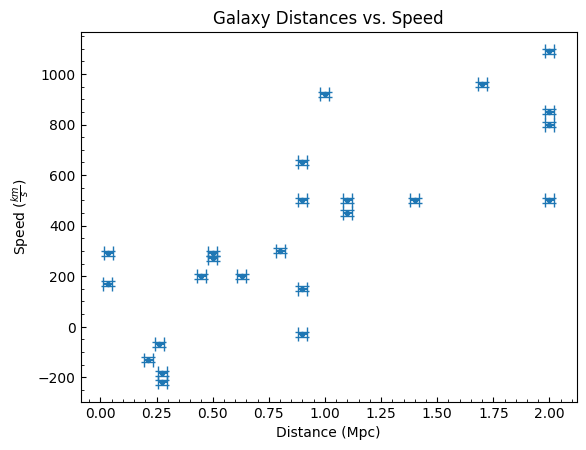

In [52]:
# Plotting with error of distance

# Distance is first column
dist, dd = hubbledat[:, 0], 0.02 # Mpc
# Speed is second column
sped, ds = hubbledat[:, 1], 10   # km/s

plt.figure()
plt.errorbar(dist, sped, xerr=dd, yerr=ds, fmt='.', capsize=5)
plt.xlabel('Distance (Mpc)')
plt.ylabel(r'Speed ($\frac{km}{s}$)')
plt.title('Galaxy Distances vs. Speed')
plt.minorticks_on()
plt.tick_params(direction='in', which='both')
plt.show()

In [53]:
# The slope of this graph will give units km/s/Mpc
# Doing a linear fit
a, b = np.polyfit(dist, sped, deg=1)

print(f"a (slope) = {a:.2f} km/s/Mpc")
print(f"b (intercept) = {b:.2f} km/s")

a (slope) = 454.16 km/s/Mpc
b (intercept) = -40.78 km/s


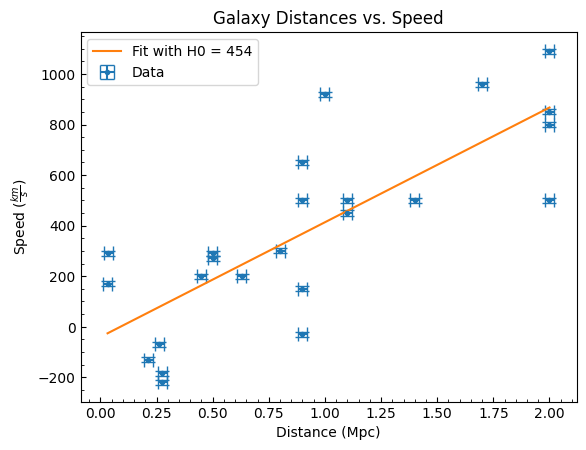

In [54]:
# Plot to verify
x = np.linspace(np.min(dist), np.max(dist), 10)
y = a * x + b

plt.figure()
plt.errorbar(dist, sped, xerr=dd, yerr=ds, fmt='.', capsize=5, label='Data')
plt.plot(x, y, '-', label=f'Fit with H0 = {int(a)}')
plt.xlabel('Distance (Mpc)')
plt.ylabel(r'Speed ($\frac{km}{s}$)')
plt.title('Galaxy Distances vs. Speed')
plt.minorticks_on()
plt.tick_params(direction='in', which='both')
plt.legend()
plt.show()

In [55]:
print(
"""
The modern Hubble constant is around 70 km/s/Mpc, so this is way off.

""")


The modern Hubble constant is around 70 km/s/Mpc, so this is way off.




In [56]:
print('Either way, the first digit is 4.')
key.append(4)

Either way, the first digit is 4.


In [57]:
print(key)

[7, 211, 8, 18, 3, 30, 4]


### 9. The RV connection (15 points)

### A few more digits to go and you have the whole key. Continuing the fitting trend you see another floppy disk with a note on it 'Which planet are these RV measurements of?' 

- If you want to refresh your memory about what an RV measurement is, check these out:
    - https://www.eso.org/public/videos/eso1035g/ 
    - https://www.planetary.org/articles/color-shifting-stars-the-radial-velocity-method 
    

- Youn insert the disk and read the data from file 'problem9_rv.csv' (2 points)
- Explore the data. Plot the data in a publication ready-plot (5 points)
- Fit the data with an appropriate model. (10 points)
- What is the amplitude and period of the data? (8 points)
- Based on your fit what is the distance of the planet to its parent star, if you assume the star has a 1.1$M_\odot$? [Tip: remember Kepler's laws] (8 points)
- Based on your fit what is the mass of the planet in Jupiter masses (use equation $M_\mathrm{pl} = M_\mathrm{star} \frac{K_\mathrm{star}}{\sqrt{GM_\mathrm{star}/r_\mathrm{AU}}}$) ? (8 points) 
- Using this table, which exoplanet do you think the data are off (1 point)? Use the mass of the planet as shown in the table (w/o the period) as the next part of the key. 


| Name of planet| Mass ($M_J$) | Period (days) |
|---|---|---|
Gliese 876 d|	0.021	| 1.938
Tau Boötis b|	8.389	| 3.312
HD 38529 b	 |   0.782	| 14.310
51 Pegasi b |	0.472 |	4.231
Gliese 876 e|	0.046 |	124.262


In [58]:
# Reading the file

prob9dat = pd.read_csv("problem9_rv.csv")
#print(prob9dat)
time9 = prob9dat['Time [days]']
rave9 = prob9dat['Radial Velocity [m/s]']
rerr9 = prob9dat['RV error [m/s]']

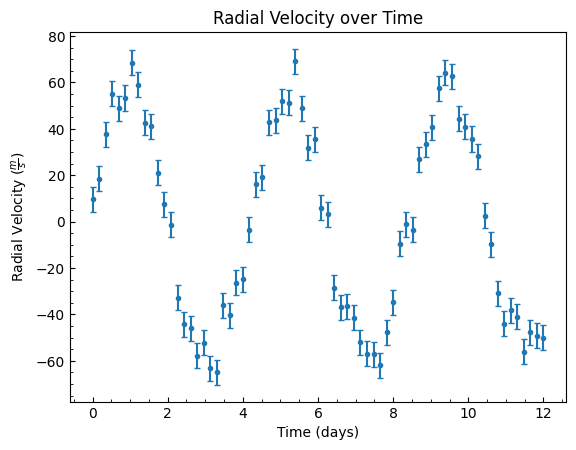

In [59]:
# Plot

plt.figure()
plt.errorbar(time9, rave9, yerr=rerr9, fmt='.', capsize=2)
plt.xlabel('Time (days)')
plt.ylabel(r'Radial Velocity ($\frac{m}{s}$)')
plt.title('Radial Velocity over Time')
plt.minorticks_on()
plt.tick_params(direction='in', which='both')
plt.show()

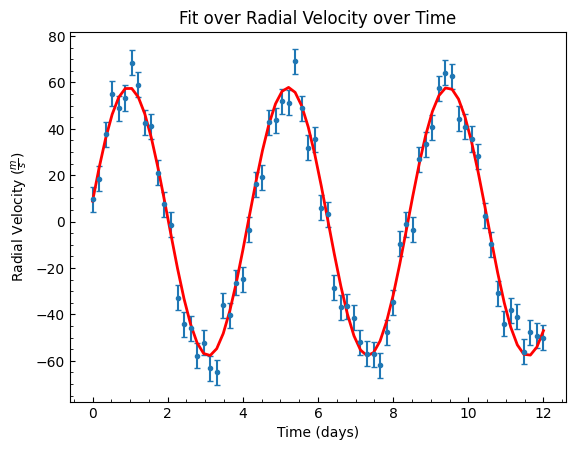

In [60]:
# Fitting data

# Appears sinusoidal
def sine(t, A, omega, phase):
    return A* np.sin(omega * t + phase)

# Initial guess
A0     = 50
omega0 = 1.5
phase0 = 0.0
p0= [A0, omega0, phase0]

# Guess
pars, _ = curve_fit(sine, time9, rave9, p0=p0, sigma=rerr9)
A, omega, phase = pars

# Plot and Values
plt.figure()
plt.errorbar(time9, rave9, yerr=rerr9, fmt='.', capsize=2)
plt.plot(time9, sine(time9, *pars), 'r-', lw=2)
plt.xlabel('Time (days)')
plt.ylabel(r'Radial Velocity ($\frac{m}{s}$)')
plt.title('Fit over Radial Velocity over Time')
plt.minorticks_on()
plt.tick_params(direction='in', which='both')
plt.show()

In [61]:
print('Amplitude = {0} m/s'.format(A))
T = 2 * np.pi / omega
print('Period = {0} days'.format(T))

Amplitude = 57.83689826335662 m/s
Period = 4.24847358554639 days


In [62]:
# Constants
G    = 6.674e-11 # m^3 kg^-1 s^-2
Msun = 1.989e30  # kg
AU   = 1.496e11   # m
Mstar = 1.1 * Msun
Tplanet = T * 24 * 60 * 60 # s

# Kepler's Third Law
# T^2 = ( ( 4 * pi^2 ) / ( G * Msun ) ) d^3
dplanet = ( ( Tplanet**2  * G * Mstar ) / ( 4 * np.pi**2 ) )**(1/3) 

print('Distance of planet to host star = {0} m'.format(dplanet))

Distance of planet to host star = 7928342829.723844 m


In [63]:
# Constants
Mjup  = 1.898e27 #kg
Kstar = A

# Calculate mass
Mplanet = Mstar * Kstar / np.sqrt( G * Mstar / dplanet)
MpJ     = Mplanet / Mjup

print('Mass of planet = {0} Mjup'.format(MpJ))

Mass of planet = 0.4912704359602681 Mjup


In [ ]:
print('My guess is 51 Pegasi b.')
print('So the next number is 0472')
key.append('0472')

My guess is 51 Pegasi b.
So the next number is 0472


In [65]:
print(key)

[7, 211, 8, 18, 3, 30, 4, '0472']


### 10. A sky full of stars (20 points)

### The end is in sight!  You walk in another room and you see the following written on a piece of paper 

<div class="alert alert-block alert-warning">
The stars are shifting, and time is running out. Hidden among the star cluster —an ancient gathering bound by motion and memory— masked by the chaos of the galaxy’s drift, are some interloppers. You’ve been given their  traces, a whisper of their journey across the sky. Study the patterns before they fade, and uncover the truth before the trail disappears into the void.  
</div>

### What does this all mean? You look around and see an image of the Pleiades on the wall. You approach and look carefully around. Behind the frame there is a usb stick. You plug it into your computer and find the file *star_motions.dat*. 

### These are data with the RA, Dec, and proper motion RA and Dec (pmRA and pmDec) of a number of stars. Most of these stars belong to the same cluster, while some are field stars that are projected in the same Field-Of-View (FOV) as the cluster. 

- Make a side-by-side plot of the (RA, Dec) and (pmRA, pmDec) of the stars (10 points)
- Knowing that stars that belong in the same group (cluster) have similar kinematics (their pmRA, pmDec is from the same parent distribution), find which stars are interlopers and which belong in the same distribution.

    - Use the sigma rejection (use a $2\sigma$ threshold) on the proper motion of the stars. How many interlopers are there in the FOV? (10 points). 
    - Append this number to your key.

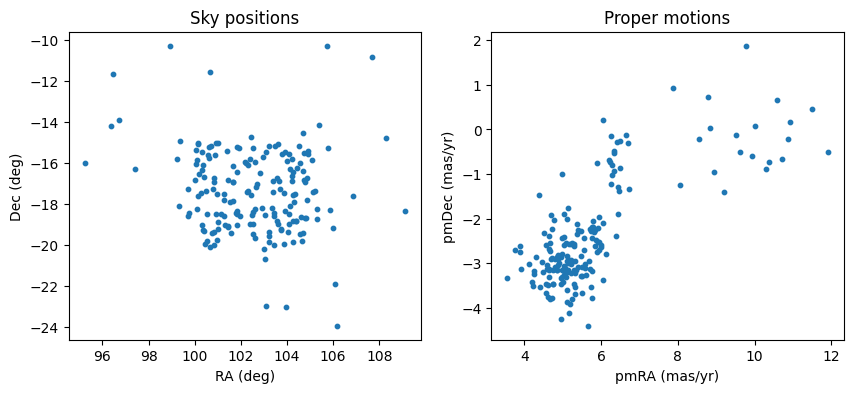

In [66]:
# (RA, Dec) and (pmRA, pmDec)

prob10dat = np.loadtxt('star_motions.dat')
#print(prob10dat)
RA, Dec = prob10dat[:, 0], prob10dat[:, 1]
pmRA, pmDec = prob10dat[:, 2], prob10dat[:, 3]

# Side-by-side
fig, ax = plt.subplots(1,2, figsize=(10,4))
ax[0].scatter(RA, Dec, s=10)
ax[0].set(xlabel="RA (deg)", ylabel="Dec (deg)", title="Sky positions")

ax[1].scatter(pmRA, pmDec, s=10)
ax[1].set(xlabel="pmRA (mas/yr)", ylabel="pmDec (mas/yr)", title="Proper motions")
plt.show()

In [67]:
# Classic sigma rejection

mu_ra   = np.mean(pmRA)
mu_dec  = np.mean(pmDec)
sig_ra  = np.std(pmRA, ddof=1)
sig_dec = np.std(pmDec, ddof=1)

# Need mask
inside = ((np.abs(pmRA - mu_ra) <= 2*sig_ra) &
         (np.abs(pmDec - mu_dec) <= 2*sig_dec))

dist   = np.where(inside)[0]    # indices of cluster members
inters = np.where(~inside)[0]   # indices of interlopers

There are 18 interlopers and 162 stars in the distribution


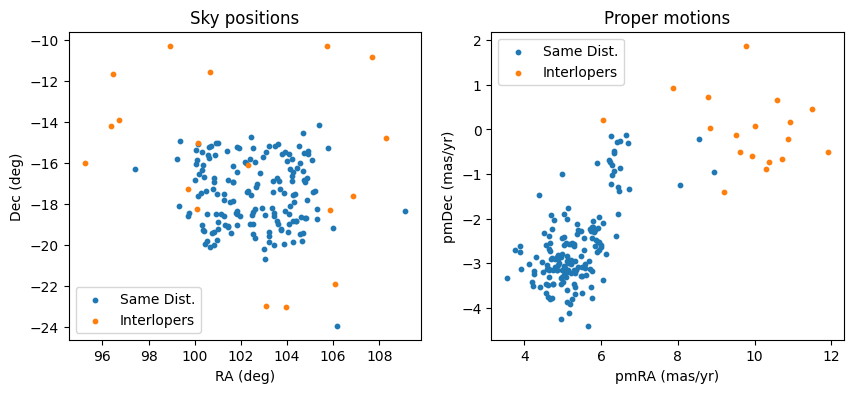

In [68]:
# Visualizing

print('There are {0} interlopers and {1} stars in the distribution'.format(len(inters), len(dist)))

# Side-by-side
fig, ax = plt.subplots(1,2, figsize=(10,4))
ax[0].scatter(RA[dist], Dec[dist], s=10, label='Same Dist.')
ax[0].scatter(RA[inters], Dec[inters], s=10, label='Interlopers')
ax[0].set(xlabel="RA (deg)", ylabel="Dec (deg)", title="Sky positions")
ax[0].legend()

ax[1].scatter(pmRA[dist], pmDec[dist], s=10, label='Same Dist.')
ax[1].scatter(pmRA[inters], pmDec[inters], s=10,label='Interlopers')
ax[1].set(xlabel="pmRA (mas/yr)", ylabel="pmDec (mas/yr)", title="Proper motions")
ax[1].legend()
plt.show()

In [70]:
print('So the number of interloper is {0} and that is the last digit.'.format(len(inters)))
key.append(18)

So the number of interloper is 18 and that is the last digit.


In [71]:
print(key)

[7, 211, 8, 18, 3, 30, 4, '0472', 18, 18]


### 11. You got the key! Will it work? Try to open file *octoknight_freed.pdf* . You did it! Octoknight will now banish the Great Pumkin king to another Universe. You saved the world! 

### Don't forget to tar.gz your file, update your log, commit one last time to GitHub and submit your Midterm! (5 points)

## Great job!

In [72]:
print(key)
print('I freed Octoknight!')

[7, 211, 8, 18, 3, 30, 4, '0472', 18, 18]
I freed Octoknight!
